In [40]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import pandas as pd
import os, glob, json
from pathlib import Path


In [41]:
# Load actual data from JSON files
json_files = list(Path('results').glob('results_*.json'))

if len(json_files) == 0:
    # Use mock data if no JSON files found
    print('No JSON files found, using mock data for demonstration...')
    sizes = ['1M', '10M', '100M', '1B']
    size_multipliers = {
        '1M': 1,
        '10M': 2,
        '100M': 4,
        '1B': 8,
    }  # Larger index = longer runtime
    nqueries_list = [1, 4402]
    nprobes = [1, 2, 4, 8, 16, 32, 64, 128, 256]

    mock_results = []
    rng = np.random.default_rng(42)
    for size in sizes:
        for n_queries in nqueries_list:
            for nprobe in nprobes:
                # Base time that increases with nprobe (higher nprobe = slower but more accurate)
                # and increases with index size
                base_time = 0.1 * (nprobe / 256) * size_multipliers[size]
                query_scaling = n_queries / 1000 if n_queries > 1 else 0.01
                mean_time = base_time * query_scaling * rng.uniform(0.8, 1.2)
                std_time = mean_time * rng.uniform(0.05, 0.15)
                mock_results.append(
                    {
                        'index_path': f'speed-test-{size}-index.bin',
                        'nprobe': nprobe,
                        'n_queries': n_queries,
                        'k': 20,
                        'embedding_dim': 2560,
                        'mean_search_time': mean_time,
                        'std_search_time': std_time,
                        'size': size,
                    }
                )
    df = pd.DataFrame(mock_results)
else:
    # Load actual JSON data
    print(f'Found {len(json_files)} JSON files, loading actual data...')
    results = []
    for json_file in json_files:
        with open(json_file, 'r') as f:
            data = json.load(f)
            # Extract size from filename
            # format: results_size_1M_nprobe_16_nq_4402.json
            filename = json_file.name
            size = filename.split('_')[2]
            data['size'] = size
            results.append(data)
    df = pd.DataFrame(results)

print(f'Loaded {len(df)} data points')
df.head()


Found 72 JSON files, loading actual data...
Loaded 72 data points


,index_path,nprobe,k,n_queries,embedding_dim,mean_search_time,std_search_time,size
0,faiss_indices/speed-test-1M-index.bin,16,20,4402,2560,2.707038,1.249045,1M
1,faiss_indices/speed-test-10M-index.bin,64,20,1,2560,0.045725,0.005416,10M
2,faiss_indices/speed-test-1M-index.bin,256,20,4402,2560,6.203725,0.389060,1M
3,faiss_indices/speed-test-1B-index.bin,8,20,1,2560,0.061629,0.004881,1B
4,faiss_indices/speed-test-1B-index.bin,256,20,4402,2560,79.202278,0.987049,1B


In [42]:
df

,index_path,nprobe,k,n_queries,embedding_dim,mean_search_time,std_search_time,size
0,faiss_indices/speed-test-1M-index.bin,16,20,4402,2560,2.707038,1.249045,1M
1,faiss_indices/speed-test-10M-index.bin,64,20,1,2560,0.045725,0.005416,10M
2,faiss_indices/speed-test-1M-index.bin,256,20,4402,2560,6.203725,0.389060,1M
3,faiss_indices/speed-test-1B-index.bin,8,20,1,2560,0.061629,0.004881,1B
4,faiss_indices/speed-test-1B-index.bin,256,20,4402,2560,79.202278,0.987049,1B
...,...,...,...,...,...,...,...,...
67,faiss_indices/speed-test-1B-index.bin,8,20,4402,2560,6.063982,0.781708,1B
68,faiss_indices/speed-test-10M-index.bin,4,20,4402,2560,0.999537,0.642569,10M
69,faiss_indices/speed-test-10M-index.bin,4,20,1,2560,0.007653,0.006653,10M
70,faiss_indices/speed-test-1M-index.bin,256,20,1,2560,0.032000,0.004793,1M


In [43]:
def plot_search_time_vs_nprobe(
    df, n_queries_val, save_path=None, figsize=(10, 7)
):
    """
    Plot mean search time vs. nprobe for a specific n_queries value.

    Parameters:
    -----------
    df : pandas.DataFrame
        DataFrame containing the benchmark results
    n_queries_val : int
        The n_queries value to filter and plot
    save_path : str, optional
        Path to save the plot as PDF. If None, plot is not saved.
    figsize : tuple, optional
        Figure size (width, height) in inches
    """
    sns.set_theme(style='whitegrid')
    plt.figure(figsize=figsize)

    # Filter data for this n_queries value
    df_filtered = df[df['n_queries'] == n_queries_val]

    if df_filtered.empty:
        print(f'No data found for n_queries = {n_queries_val}')
        return

    annotation_offset = (
        df_filtered['mean_search_time'].max() * 0.02
    )  # Dynamic offset

    # Define the order of index sizes and color palette
    size_order = ['1M', '10M', '100M', '1B']
    colors = sns.color_palette('viridis', len(size_order))[
        ::-1
    ]  # viridis palette reversed (light to dark as size increases)

    for i, size in enumerate(size_order):
        if size not in df_filtered['size'].values:
            continue  # Skip if this size is not in the data

        group = df_filtered[df_filtered['size'] == size]
        # Sort by nprobe
        group = group.sort_values('nprobe')
        label = size
        color = colors[i]

        scatter = sns.scatterplot(
            x=group['nprobe'],
            y=group['mean_search_time'],
            s=100,
            edgecolor='black',
            color=color,
            label=label,
        )
        plt.plot(
            group['nprobe'],
            group['mean_search_time'],
            linestyle='-',
            marker='',
            color=color,
            alpha=0.7,
        )

    # Limit the number of y-ticks to a maximum of 7
    plt.gca().yaxis.set_major_locator(ticker.MaxNLocator(nbins=7))

    # Format y-axis labels to two decimal places
    plt.gca().yaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))

    # Use log scale for x-axis but show actual nprobe values as tick labels
    plt.xscale('log', base=2)
    nprobe_values = sorted(df_filtered['nprobe'].unique())
    plt.xticks(nprobe_values, [str(x) for x in nprobe_values])

    # Labels and title
    plt.xlabel('nprobe', fontsize=12)
    plt.ylabel('Mean Search Time (s)', fontsize=12)
    plt.title(
        f'IVF Search: Mean Search Time vs. nprobe (n_queries = {n_queries_val})'
    )

    # Set the legend location with reversed order and title
    handles, labels = plt.gca().get_legend_handles_labels()
    plt.legend(
        handles[::-1], labels[::-1], loc='upper left', title='Index Size'
    )

    # Adjust grid line appearance (lighter)
    plt.grid(True, linewidth=0.5, alpha=0.4)

    plt.tight_layout()

    # Save the plot as a high-resolution PDF if path provided
    if save_path:
        plt.savefig(save_path, format='pdf', dpi=300)
        print(f'Plot saved to: {save_path}')

    plt.show()


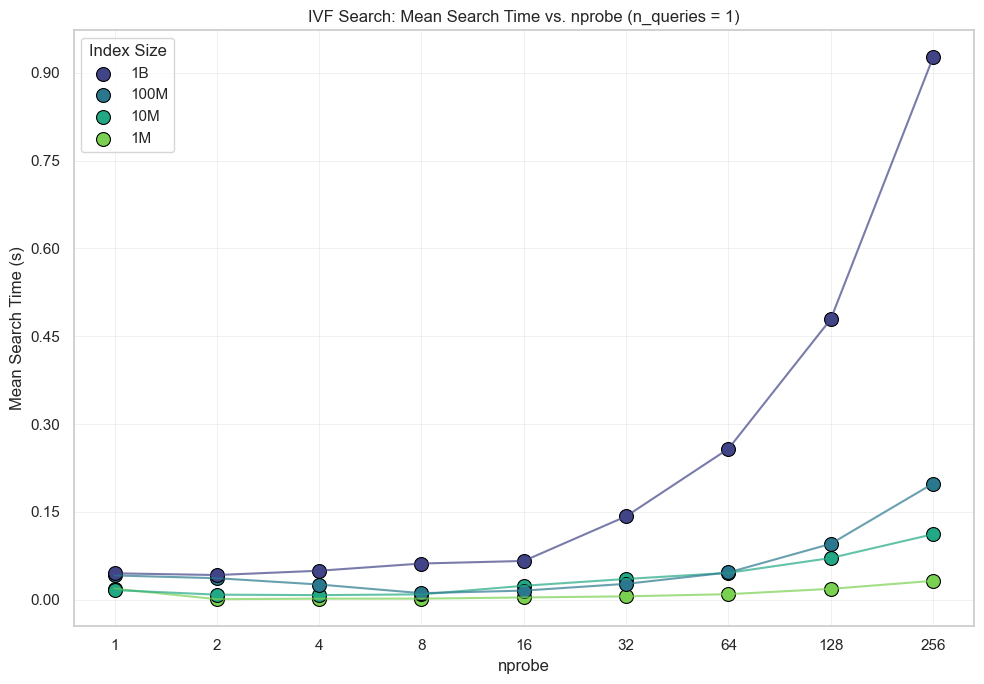

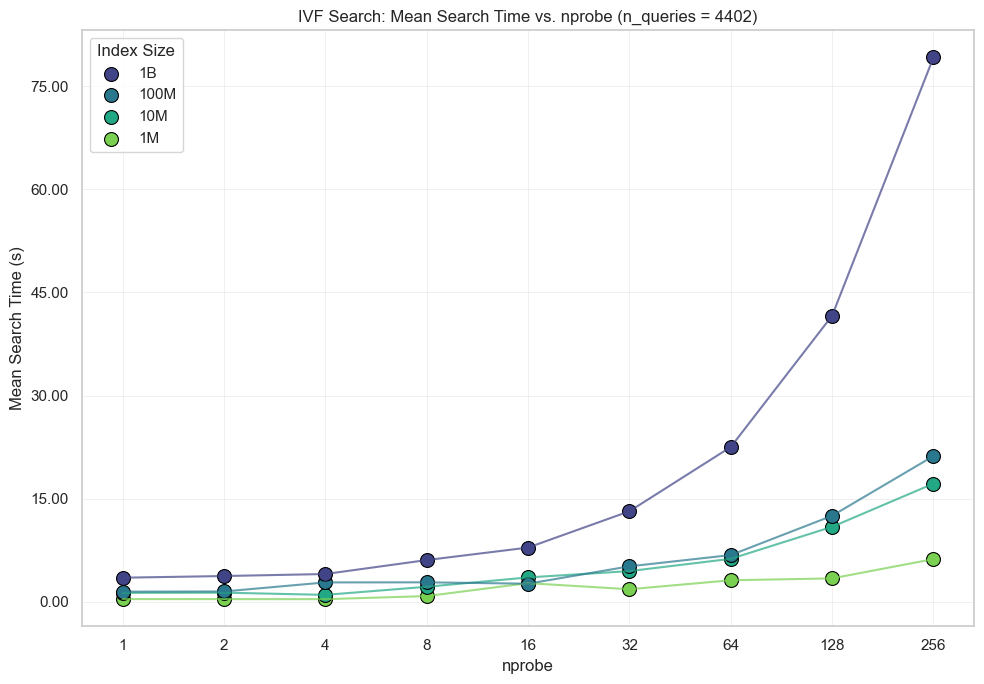

In [44]:
# Generate plots for each n_queries value
for n_queries_val in sorted(df['n_queries'].unique()):
    # Optional: save each plot to PDF
    # save_path = f'ivf_search_time_vs_nprobe_nq_{n_queries_val}.pdf'
    save_path = None  # Set to None to not save

    plot_search_time_vs_nprobe(df, n_queries_val, save_path=save_path)
